## <center>CSE 546: Reinforcement Learning</center>
### <center>Prof. Alina Vereshchaka</center>
#### <center>Spring 2026</center>

Welcome to the Assignment 3, Part 1: Introduction to Actor-Critic Methods! It includes the implementation of simple actor and critic networks and best practices used in modern Actor-Critic algorithms.

## Section 0: Setup and Imports

In [ ]:
# Install required packages for all Task 2 environments
import subprocess, sys

# ale-py provides Atari ROMs for PongNoFrameskip-v4
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ale-py', '-q'], check=False)

# gymnasium[mujoco] provides HalfCheetah-v5 and other MuJoCo environments
subprocess.run([sys.executable, '-m', 'pip', 'install', 'gymnasium[mujoco]', '-q'], check=False)

print('ale-py and gymnasium[mujoco] ready.')


ale-py and gymnasium[mujoco] ready.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import gymnasium.spaces as spaces

# Register Atari environments (ale-py) so PongNoFrameskip-v4 is available
try:
    import ale_py
    gym.register_envs(ale_py)
except ImportError:
    pass  # ale-py not installed; Atari envs will be unavailable

import matplotlib.pyplot as plt
from collections import deque

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Actor-Critic Network Architectures and Loss Computation

We build two common actor-critic layouts and write the losses with small dummy tensors.

- **A. Two separate networks** — actor and critic each have their own weights.
- **B. One shared body, two heads** — the same hidden layers feed the policy output and the value output.

Both are common. A shared body is usually smaller and can train a bit faster. Separate nets are easier to tune or change one side only.

---


### Task 1a – Separate Actor and Critic Networks with Loss Function

Define a class `SeparateActorCritic`. The goal is to:
- Create two completely independent neural networks: one for the actor and one for the critic.
- The actor should output a probability distribution over discrete actions (use `nn.Softmax`).
- The critic should output a single scalar value.

 Use `nn.ReLU()` as the activation function. Include at least one hidden layer of reasonable width (e.g. 64 or 128 units).

```python

```

 Next, simulate training using dummy tensors:
1. Generate dummy tensors for log-probabilities, returns, estimated values, and entropies.
2. Compute the actor loss using the advantage (return - value).
3. Compute the critic loss as mean squared error between values and returns.
4. Use a single optimizer for both the Actor and the Critic. In this case, combine the actor and critic losses into a total loss and perform backpropagation.
5. Use a separate optimizers for both the Actor and the Critic. In this case, keep the actor and critic losses separate and perform backpropagation.

```python

```

🔗 Helpful references:
- PyTorch Softmax: https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html
- PyTorch MSE Loss: https://pytorch.org/docs/stable/generated/torch.nn.functional.mse_loss.html

---

In [2]:

# TASK 1a: Separate Actor and Critic Networks
# Two completely independent networks share NO weights.
# Actor  → maps state to action probability distribution
# Critic → maps state to a single scalar value V(s)




# ── Actor Network ────────────────────────────────────────────────────────────
class SeparateActorNetwork(nn.Module):
    """
    Standalone Actor network.
    Input : state vector  (input_dim,)
    Output: action probability distribution  (n_actions,)  via Softmax
    Architecture: Linear → ReLU → Linear → Softmax
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_actions: int):
        super(SeparateActorNetwork, self).__init__()
        self.fc1    = nn.Linear(input_dim, hidden_dim)   # hidden layer
        self.fc2    = nn.Linear(hidden_dim, n_actions)   # output layer

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))           # activate hidden layer
        return F.softmax(self.fc2(x), dim=-1)  # normalised action probabilities


# ── Critic Network ───────────────────────────────────────────────────────────
class SeparateCriticNetwork(nn.Module):
    """
    Standalone Critic network.
    Input : state vector  (input_dim,)
    Output: scalar state-value  V(s)
    Architecture: Linear → ReLU → Linear (1 output neuron)
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        super(SeparateCriticNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # hidden layer
        self.fc2 = nn.Linear(hidden_dim, 1)          # scalar value output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        return self.fc2(x)   # shape: (batch, 1)


# ── Wrapper that holds both independent networks ──────────────────────────────
class SeparateActorCritic(nn.Module):
    """
    Wraps the two completely independent Actor and Critic networks.
    No parameters are shared between them.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128, n_actions: int = 4):
        super(SeparateActorCritic, self).__init__()
        self.actor  = SeparateActorNetwork(input_dim, hidden_dim, n_actions)
        self.critic = SeparateCriticNetwork(input_dim, hidden_dim)

    def forward(self, x: torch.Tensor):
        action_probs = self.actor(x)   # (batch, n_actions)
        value        = self.critic(x)  # (batch, 1)
        return action_probs, value



# Hyperparameters for the dummy simulation

INPUT_DIM  = 8    # observation vector size (e.g. LunarLander has 8 features)
HIDDEN_DIM = 128  # width of hidden layer
N_ACTIONS  = 4    # number of discrete actions
BATCH_SIZE = 32   # mini-batch size
LR         = 1e-3 # learning rate
ENT_COEF   = 0.01 # entropy bonus coefficient (encourages exploration)
VF_COEF    = 0.5  # value-function loss coefficient

# Instantiate the model
sep_model = SeparateActorCritic(INPUT_DIM, HIDDEN_DIM, N_ACTIONS)
print("SeparateActorCritic architecture:")
print(sep_model)

# ── Dummy input observations ──────────────────────────────────────────────────
dummy_obs     = torch.randn(BATCH_SIZE, INPUT_DIM)   # fake state batch
dummy_returns = torch.randn(BATCH_SIZE, 1)           # discounted returns G_t


def compute_losses(model, obs, returns):
    """
    Runs a forward pass and returns actor_loss, critic_loss.

    Actor loss  = -E[log π(a|s) * A(s,a)] - entropy_bonus
      where advantage  A(s,a) = returns - V(s)   (critic is not updated here)

    Critic loss = MSE(V(s), returns)
    """
    action_probs, values = model(obs)   # forward pass

    # Advantage: how much better the sampled action was vs. baseline V(s)
    # .detach() stops gradients flowing through the advantage into the critic
    advantages = returns - values.detach()   # shape: (batch, 1)

    # Sample actions from the policy and compute log-probabilities
    dist      = torch.distributions.Categorical(action_probs)
    actions   = dist.sample()            # (batch,)
    log_probs = dist.log_prob(actions)   # (batch,)
    entropy   = dist.entropy()           # (batch,) — maximised to encourage exploration

    # Actor loss: policy gradient loss minus entropy bonus
    actor_loss  = -(log_probs * advantages.squeeze()).mean() - ENT_COEF * entropy.mean()

    # Critic loss: MSE between estimated value and actual discounted return
    critic_loss = F.mse_loss(values.squeeze(), returns.squeeze())

    return actor_loss, critic_loss


#
# CASE 1 — Single Combined Optimizer
# 
# One Adam optimizer is passed ALL parameters (actor + critic combined).
# The total loss combines both losses with the value-function coefficient.
print("\n── Case 1: Single Combined Optimizer ──")

sep_model_1  = SeparateActorCritic(INPUT_DIM, HIDDEN_DIM, N_ACTIONS)
optimizer_1  = optim.Adam(
    list(sep_model_1.actor.parameters()) + list(sep_model_1.critic.parameters()),
    lr=LR
)

actor_loss_1, critic_loss_1 = compute_losses(sep_model_1, dummy_obs, dummy_returns)
total_loss_1 = actor_loss_1 + VF_COEF * critic_loss_1  # weighted combination

optimizer_1.zero_grad()     # clear accumulated gradients
total_loss_1.backward()     # back-propagate total loss
optimizer_1.step()          # update all parameters in one step

print(f"  Actor Loss  : {actor_loss_1.item():.4f}")
print(f"  Critic Loss : {critic_loss_1.item():.4f}")
print(f"  Total Loss  : {total_loss_1.item():.4f}")
print("  Single optimizer step applied successfully.")



# CASE 2 — Separate Optimizers for Actor and Critic

# Two Adam optimizers — each sees only its own network's parameters.
# Losses are kept separate and backpropagated independently.
print("\n── Case 2: Separate Optimizers ──")

sep_model_2       = SeparateActorCritic(INPUT_DIM, HIDDEN_DIM, N_ACTIONS)
actor_optimizer   = optim.Adam(sep_model_2.actor.parameters(),  lr=LR)
critic_optimizer  = optim.Adam(sep_model_2.critic.parameters(), lr=LR)

actor_loss_2, critic_loss_2 = compute_losses(sep_model_2, dummy_obs, dummy_returns)

# ── Update Actor ──────────────────────────────────────────────────────────────
actor_optimizer.zero_grad()
actor_loss_2.backward(retain_graph=True)  # retain graph so critic can still use it
actor_optimizer.step()

# ── Update Critic ─────────────────────────────────────────────────────────────
critic_optimizer.zero_grad()
critic_loss_2.backward()   # critic loss uses the retained graph
critic_optimizer.step()

print(f"  Actor Loss  : {actor_loss_2.item():.4f}")
print(f"  Critic Loss : {critic_loss_2.item():.4f}")
print("  Separate optimizer steps applied successfully.")



SeparateActorCritic architecture:
SeparateActorCritic(
  (actor): SeparateActorNetwork(
    (fc1): Linear(in_features=8, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=4, bias=True)
  )
  (critic): SeparateCriticNetwork(
    (fc1): Linear(in_features=8, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=1, bias=True)
  )
)

── Case 1: Single Combined Optimizer ──
  Actor Loss  : -0.0282
  Critic Loss : 1.6085
  Total Loss  : 0.7760
  Single optimizer step applied successfully.

── Case 2: Separate Optimizers ──
  Actor Loss  : -0.0780
  Critic Loss : 1.4557
  Separate optimizer steps applied successfully.


### Discussion – Task 1a: Why separate actor and critic?

With **two networks**, each side has its own weights and gradients. People use this when:

- The value net learns faster than the policy. You might use a higher learning rate for the critic and a lower one for the actor.
- The two parts need different layers (for example images vs a short vector).
- You want to freeze, swap, or debug one network without touching the other.

You can use one optimizer for both, or two optimizers if you want different step sizes.

Downside: more parameters, and you do not share features between actor and critic.


### Task 1b – Shared Network with Actor and Critic Heads + Loss Function

Now define a class `SharedActorCritic`:
- Build a shared base network (e.g., linear layer + ReLU)
- Create two heads: one for actor (output action probabilities) and one for critic (output state value)



Then:
1. Pass a dummy input tensor through the model to obtain action probabilities and value.
2. Simulate dummy rewards and compute advantage.
3. Compute the actor and critic losses, combine them, and backpropagate.



 Use `nn.Softmax` for actor output and `nn.Linear` for scalar critic output.

🔗 More reading:
- Policy Gradient Methods: https://spinningup.openai.com/en/latest/algorithms/vpg.html
- Actor-Critic Overview: https://www.tensorflow.org/agents/tutorials/6_reinforce_tutorial
- PyTorch Categorical Distribution: https://pytorch.org/docs/stable/distributions.html#categorical

---

In [3]:

# TASK 1b: Shared Network with Two Output Heads

# A single backbone extracts features from the input state.
# Two separate linear heads branch off the backbone:
#   • Actor head  → action probabilities  (Softmax)
#   • Critic head → scalar state value    (linear, no activation)


class SharedActorCritic(nn.Module):
    """
    Shared-backbone Actor-Critic network.

    Architecture:
        Input  → [Shared: Linear → ReLU]
                         ↓              ↓
               [Actor head: Linear+Softmax]  [Critic head: Linear]
               → action probabilities         → scalar V(s)
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128, n_actions: int = 4):
        super(SharedActorCritic, self).__init__()

        # ── Shared backbone: learns general state representations ──────────────
        self.shared_layer = nn.Linear(input_dim, hidden_dim)

        # ── Actor head: transforms shared features → action distribution ───────
        self.actor_head   = nn.Linear(hidden_dim, n_actions)

        # ── Critic head: transforms shared features → scalar value V(s) ────────
        self.critic_head  = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor):
        # Pass input through shared backbone
        shared_features = F.relu(self.shared_layer(x))  # (batch, hidden_dim)

        # Actor head: output a probability distribution over actions
        action_probs = F.softmax(self.actor_head(shared_features), dim=-1)  # (batch, n_actions)

        # Critic head: output a scalar state-value estimate
        state_value  = self.critic_head(shared_features)   # (batch, 1)

        return action_probs, state_value


# ── Instantiate the shared model ──────────────────────────────────────────────
shared_model = SharedActorCritic(INPUT_DIM, HIDDEN_DIM, N_ACTIONS)
print("SharedActorCritic architecture:")
print(shared_model)

# ── Single optimizer over ALL parameters (shared + both heads) ───────────────
# This is the most common setup for shared networks.
optimizer_shared = optim.Adam(shared_model.parameters(), lr=LR)

# ── Forward pass with dummy data ──────────────────────────────────────────────
action_probs, values = shared_model(dummy_obs)

# Advantage = actual discounted return - estimated baseline V(s)
# .detach() prevents gradients from the advantage term updating the critic twice
advantages = dummy_returns - values.detach()   # (batch, 1)

# ── Sample actions and compute log-probabilities ──────────────────────────────
dist      = torch.distributions.Categorical(action_probs)
actions   = dist.sample()             # (batch,)
log_probs = dist.log_prob(actions)    # (batch,)
entropy   = dist.entropy()            # (batch,)  — promotes exploration

# ── Loss computation ──────────────────────────────────────────────────────────
# Actor loss: policy gradient with entropy bonus
#   - Negative because we want to maximise expected return (gradient ascent)
#   - Entropy term discourages premature convergence to deterministic policies
actor_loss_shared  = -(log_probs * advantages.squeeze()).mean() - ENT_COEF * entropy.mean()

# Critic loss: MSE between predicted value and actual discounted return
critic_loss_shared = F.mse_loss(values.squeeze(), dummy_returns.squeeze())

# Combined total loss with value-function coefficient
total_loss_shared  = actor_loss_shared + VF_COEF * critic_loss_shared

# ── Backpropagation ───────────────────────────────────────────────────────────
optimizer_shared.zero_grad()     # zero out any previously accumulated gradients
total_loss_shared.backward()     # compute gradients w.r.t. all parameters
optimizer_shared.step()          # update all parameters simultaneously

print(f"\n  Actor Loss  : {actor_loss_shared.item():.4f}")
print(f"  Critic Loss : {critic_loss_shared.item():.4f}")
print(f"  Total Loss  : {total_loss_shared.item():.4f}")
print("  Shared network optimizer step applied successfully.")



SharedActorCritic architecture:
SharedActorCritic(
  (shared_layer): Linear(in_features=8, out_features=128, bias=True)
  (actor_head): Linear(in_features=128, out_features=4, bias=True)
  (critic_head): Linear(in_features=128, out_features=1, bias=True)
)

  Actor Loss  : 0.1444
  Critic Loss : 1.6296
  Total Loss  : 0.9592
  Shared network optimizer step applied successfully.


### Discussion – Task 1b: Why a shared network?

One **shared trunk** means actor and critic use the same hidden features.

- **Smaller model** — one set of hidden layers, not two copies.
- **More learning per step** — both losses update the trunk.
- **Often quicker early on** — the trunk must learn features that help both action choice and value prediction.

Problem: the two losses can pull the trunk in different directions. That is why we scale the value loss (`vf_coef`, here 0.5) and add entropy for the policy.

Many actor-critic codes use a shared trunk, especially for images.


## Section 2: Auto-Adaptive Network Setup for Environments

We add a helper that **reads the environment** and builds a shared actor-critic with the right input and output layers.


### Task 2: Auto-generate Input and Output Layers
Write a function `create_shared_network(env)` that constructs a neural network using the following rules:
- The input layer should match the environment's observation space.
- The output layer for the **actor** should depend on the action space:
  - For discrete actions: output probabilities using `nn.Softmax`.
  - For continuous actions: output mean and log std for a Gaussian distribution.
- The **critic** always outputs a single scalar value.

```python
```

#### Environments to Support:
Test the function with the following environments:
1. `CliffWalking-v0` (Use one-hot encoding for discrete integer observations.)
2. `LunarLander-v3` (Standard Box space for observations and discrete actions.)
3. `PongNoFrameskip-v4` (Use gym wrappers for Atari image preprocessing.)
4. `HalfCheetah-v5` (Continuous observation and continuous action.)

```python

```

Hint: Use `gym.spaces` utilities to determine observation/action types dynamically.

🔗 Observation/Action Space Docs:
- https://gymnasium.farama.org/api/spaces/

---

In [4]:

# TASK 2: Auto-generate Actor-Critic Networks Based on Environment Spaces

# The function create_shared_network(env) inspects the observation and action
# spaces at runtime and builds the appropriate network architecture.
#
# Supported observation spaces:
#   • gym.spaces.Discrete  → one-hot encode → MLP input
#   • gym.spaces.Box 1-D   → MLP input  (e.g. LunarLander)
#   • gym.spaces.Box 3-D   → CNN input  (e.g. Atari images H×W×C)
#
# Supported action spaces:
#   • gym.spaces.Discrete       → Softmax probabilities
#   • gym.spaces.Box            → Gaussian mean + log-std (continuous)
#   • gym.spaces.MultiDiscrete  → per-dimension Softmax heads




# ── CNN Feature Extractor for image-based observations ────────────────────────
class CNNFeatureExtractor(nn.Module):
    """
    Three-layer convolutional feature extractor for Atari-style image observations.
    Expects observation shape (H, W, C) as returned by Gymnasium (channels-last).
    Internally permutes to (B, C, H, W) for PyTorch convolutions.

    Architecture (standard DQN / A3C CNN):
        Conv2d(C→32, 8×8, stride 4) → ReLU
        Conv2d(32→64, 4×4, stride 2) → ReLU
        Conv2d(64→64, 3×3, stride 1) → ReLU
        Flatten
    """
    def __init__(self, obs_shape: tuple):
        super(CNNFeatureExtractor, self).__init__()

        # Gymnasium returns (H, W, C); we read channels from the last dimension
        H, W, C = obs_shape[0], obs_shape[1], obs_shape[2]

        self.cnn = nn.Sequential(
            nn.Conv2d(C,  32, kernel_size=8, stride=4),  # downsample aggressively
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()                                  # flatten to 1-D vector
        )

        # Compute the flattened output dimension using a dummy forward pass
        # (avoids manually calculating the spatial output of convolutions)
        with torch.no_grad():
            dummy = torch.zeros(1, C, H, W)   # (B, C, H, W)
            self.output_dim = self.cnn(dummy).shape[1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x is expected as (B, H, W, C); permute to (B, C, H, W) for Conv2d."""
        if x.dim() == 3:               # single obs → add batch dimension
            x = x.unsqueeze(0)
        x = x.permute(0, 3, 1, 2).float() / 255.0   # normalise to [0, 1]
        return self.cnn(x)


# ── Adaptive Shared Actor-Critic Network ──────────────────────────────────────
class AdaptiveSharedNetwork(nn.Module):
    """
    Auto-builds a shared Actor-Critic network for any Gymnasium environment.

    The constructor inspects obs_space and action_space and builds:
      1. An appropriate feature extractor (MLP or CNN)
      2. An actor head matching the action space type
      3. A critic head (always a single linear output)
    """
    def __init__(self, obs_space, action_space, hidden_dim: int = 256):
        super(AdaptiveSharedNetwork, self).__init__()

        self.obs_space    = obs_space
        self.action_space = action_space
        self.obs_type     = None   # set below based on space type
        self.action_type  = None

        # ── STEP 1: Build feature extractor based on observation space ──────────

        if isinstance(obs_space, spaces.Discrete):
            # e.g. CliffWalking-v0: observation is an integer index → one-hot encode
            self.obs_type    = 'discrete'
            self.n_obs       = obs_space.n           # number of states
            feature_dim      = obs_space.n           # one-hot vector length
            self.feature_net = nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),  # project one-hot to hidden
                nn.ReLU()
            )

        elif isinstance(obs_space, spaces.Box):
            if len(obs_space.shape) == 1:
                # e.g. LunarLander-v3, HalfCheetah-v5: flat observation vector
                self.obs_type    = 'box_vector'
                feature_dim      = obs_space.shape[0]
                self.feature_net = nn.Sequential(
                    nn.Linear(feature_dim, hidden_dim),
                    nn.ReLU()
                )
            else:
                # e.g. PongNoFrameskip-v4: image (H, W, C)
                self.obs_type    = 'box_image'
                self.cnn         = CNNFeatureExtractor(obs_space.shape)
                feature_dim      = self.cnn.output_dim
                # Additional linear layer after CNN to project to hidden_dim
                self.feature_net = nn.Sequential(
                    nn.Linear(feature_dim, hidden_dim),
                    nn.ReLU()
                )
        else:
            raise ValueError(f"Unsupported observation space: {type(obs_space)}")

        # ── STEP 2: Build actor head based on action space ──────────────────────

        if isinstance(action_space, spaces.Discrete):
            # Discrete actions → single linear layer + Softmax
            self.action_type  = 'discrete'
            self.actor_head   = nn.Linear(hidden_dim, action_space.n)

        elif isinstance(action_space, spaces.Box):
            # Continuous actions → output Gaussian mean; log_std as learnable parameter
            self.action_type      = 'continuous'
            action_dim            = action_space.shape[0]
            self.actor_mean_head  = nn.Linear(hidden_dim, action_dim)
            # log_std is a learnable vector (not conditioned on state, common in practice)
            self.actor_log_std    = nn.Parameter(torch.zeros(action_dim))

        elif isinstance(action_space, spaces.MultiDiscrete):
            # Multi-discrete → one softmax head per sub-action dimension
            self.action_type  = 'multi_discrete'
            self.actor_heads  = nn.ModuleList([
                nn.Linear(hidden_dim, int(n)) for n in action_space.nvec
            ])
        else:
            raise ValueError(f"Unsupported action space: {type(action_space)}")

        # ── STEP 3: Critic head — always a scalar V(s) ──────────────────────────
        self.critic_head = nn.Linear(hidden_dim, 1)

    # ── Feature extraction helper ─────────────────────────────────────────────
    def _extract_features(self, obs: torch.Tensor) -> torch.Tensor:
        if self.obs_type == 'discrete':
            # Convert integer index to one-hot vector
            obs = F.one_hot(obs.long(), num_classes=self.n_obs).float()
            return self.feature_net(obs)
        elif self.obs_type == 'box_image':
            # Pass through CNN, then projection layer
            cnn_out = self.cnn(obs)
            return self.feature_net(cnn_out)
        else:  # 'box_vector'
            return self.feature_net(obs.float())

    def forward(self, obs: torch.Tensor):
        # 1. Extract shared features
        features = self._extract_features(obs)   # (batch, hidden_dim)

        # 2. Critic: state-value estimate
        value = self.critic_head(features)        # (batch, 1)

        # 3. Actor: action outputs depend on action space type
        if self.action_type == 'discrete':
            action_probs = F.softmax(self.actor_head(features), dim=-1)
            return action_probs, value

        elif self.action_type == 'continuous':
            mean    = self.actor_mean_head(features)        # (batch, action_dim)
            log_std = self.actor_log_std.expand_as(mean)    # broadcast to batch
            return (mean, log_std), value

        elif self.action_type == 'multi_discrete':
            # One probability vector per sub-action dimension
            probs = [F.softmax(head(features), dim=-1) for head in self.actor_heads]
            return probs, value


# ── Public API ────────────────────────────────────────────────────────────────
def create_shared_network(env, hidden_dim: int = 256) -> AdaptiveSharedNetwork:
    """
    Dynamically builds a shared Actor-Critic network for any Gymnasium environment.

    Args:
        env        : A Gymnasium environment instance (must be already created).
        hidden_dim : Width of the shared hidden layer (default 256).

    Returns:
        AdaptiveSharedNetwork — a PyTorch nn.Module ready for training.
    """
    return AdaptiveSharedNetwork(
        obs_space    = env.observation_space,
        action_space = env.action_space,
        hidden_dim   = hidden_dim
    )


# ── Test across all required environments ─────────────────────────────────────
# Each environment is created, a network is built, and a dummy forward pass
# is executed to confirm the shapes are correct.

test_envs = [
    ("CliffWalking-v1",       {},                          "Discrete obs (int → one-hot → 48 states), Discrete action (4)"),
    ("LunarLander-v3",        {},                          "Box obs (8-D vector), Discrete action"),
    ("PongNoFrameskip-v4",    {},                          "Box obs (210×160×3 image), Discrete action"),
    ("HalfCheetah-v5",        {},                          "Box obs (17-D vector), Box action (6-D continuous)"),
]

for env_id, env_kwargs, description in test_envs:
    print(f"\n{'─'*65}")
    print(f"  Environment : {env_id}")
    print(f"  Description : {description}")

    try:
        env = gym.make(env_id, **env_kwargs)
        obs_space    = env.observation_space
        action_space = env.action_space

        print(f"  Obs space   : {obs_space}")
        print(f"  Action space: {action_space}")

        # Build the network dynamically
        network = create_shared_network(env)
        print(f"  Network     : {network.__class__.__name__}")
        print(f"  Obs type    : {network.obs_type}")
        print(f"  Action type : {network.action_type}")

        # ── Dummy forward pass ────────────────────────────────────────────────
        obs_raw, _ = env.reset(seed=SEED)

        if network.obs_type == 'discrete':
            # CliffWalking returns a scalar integer
            obs_tensor = torch.tensor([obs_raw], dtype=torch.long)  # (1,)
        elif network.obs_type == 'box_image':
            obs_tensor = torch.tensor(obs_raw, dtype=torch.float32).unsqueeze(0)  # (1,H,W,C)
        else:
            obs_tensor = torch.tensor(obs_raw, dtype=torch.float32).unsqueeze(0)  # (1, obs_dim)

        with torch.no_grad():
            actor_out, value = network(obs_tensor)

        # Print output shapes
        if network.action_type == 'discrete':
            print(f"  Actor output shape  : {actor_out.shape}  (action probabilities)")
        elif network.action_type == 'continuous':
            mean, log_std = actor_out
            print(f"  Actor mean shape    : {mean.shape}  | log_std shape: {log_std.shape}")
        elif network.action_type == 'multi_discrete':
            print(f"  Actor output shapes : {[p.shape for p in actor_out]}")

        print(f"  Critic output shape : {value.shape}  (scalar V(s))")
        print(f"  ✓ Forward pass successful")

        env.close()

    except Exception as e:
        print(f"  ✗ Could not test {env_id}: {e}")
        print(f"    (Install required packages: e.g. ale-py for Atari, mujoco for HalfCheetah)")




─────────────────────────────────────────────────────────────────
  Environment : CliffWalking-v1
  Description : Discrete obs (int → one-hot → 48 states), Discrete action (4)
  Obs space   : Discrete(48)
  Action space: Discrete(4)
  Network     : AdaptiveSharedNetwork
  Obs type    : discrete
  Action type : discrete
  Actor output shape  : torch.Size([1, 4])  (action probabilities)
  Critic output shape : torch.Size([1, 1])  (scalar V(s))
  ✓ Forward pass successful

─────────────────────────────────────────────────────────────────
  Environment : LunarLander-v3
  Description : Box obs (8-D vector), Discrete action
  Obs space   : Box([-2.5 -2.5 -10. -10. -6.28 -10. -0. -0.], [2.5 2.5 10. 10. 6.28 10. 1. 1.], (8,), float32)
  Action space: Discrete(4)
  Network     : AdaptiveSharedNetwork
  Obs type    : box_vector
  Action type : discrete
  Actor output shape  : torch.Size([1, 4])  (action probabilities)
  Critic output shape : torch.Size([1, 1])  (scalar V(s))
  ✓ Forward pass su

### Discussion – Task 2: Why build the net from the environment?

`create_shared_network(env)` means: **match the observation and action spaces** so one code path works on many tasks.

**Observations:**
- **Discrete** (grid index): use **one-hot** so the model does not treat the index like a normal number.
- **Box vector** (LunarLander): use an **MLP**.
- **Box image** (Pong): use a **CNN**, then an MLP.

**Actions:**
- **Discrete**: **Softmax** for action probabilities.
- **Continuous Box**: **mean** (and learned log std) for a Gaussian policy.
- **MultiDiscrete**: one **Softmax** per part of the action.

The **critic** always outputs **one scalar** `V(s)`.


### Task 3: Write Observation Normalization Function
Create a function `normalize_observation(obs, env)` that:
- Checks if the observation space is `Box` and has `low` and `high` attributes.
- If so, normalize the input observation.
- Otherwise, return the observation unchanged.

```python
#  Define `normalize_observation(obs, env)`
```

Test this function with observations from:
- `LunarLander-v3`
- `PongNoFrameskip-v4`

Note: Atari observations are image arrays. Normalize pixel values to [0, 1]. For LunarLander-v3, the different elements in the observation vector have different ranges. Normalize them to [0, 1] using the `low` and `high` attributes of the observation space.


---

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3: Observation Normalization
# ─────────────────────────────────────────────────────────────────────────────
# Normalizing observations before feeding them into a neural network is a
# standard preprocessing step that:
#   • Prevents features with large absolute values from dominating gradients.
#   • Keeps activations in a well-behaved range, avoiding saturation.
#   • Makes training more stable and often faster.
#
# Strategy:
#   • Box spaces (vector): normalise per-element to [0, 1] using obs_space.low/high
#   • Box spaces (image) : normalise pixel values to [0, 1] by dividing by 255
#   • Non-Box spaces     : return the observation unchanged



def normalize_observation(obs, env) -> np.ndarray:
    """
    Normalises a raw Gymnasium observation to the [0, 1] range.

    Rules applied:
        1. If obs_space is NOT a Box (e.g. Discrete), return obs unchanged.
        2. If obs_space is a Box with image dimensions (3-D: H×W×C),
           divide by 255 to map uint8 pixels to [0, 1].
        3. If obs_space is a Box with a 1-D vector, apply per-element
           min-max normalisation using the space's .low and .high bounds:
               obs_norm[i] = (obs[i] - low[i]) / (high[i] - low[i])
           Dimensions that are unbounded (±inf) are left unchanged because
           a principled normalisation range cannot be defined.

    Args:
        obs : Raw observation from env.reset() or env.step().
        env : The Gymnasium environment instance.

    Returns:
        Normalised observation as a numpy float32 array (or original if non-Box).
    """
    obs_space = env.observation_space

    # ── Non-Box spaces: no normalisation defined ──────────────────────────────
    if not isinstance(obs_space, gym.spaces.Box):
        return obs   # e.g. Discrete observation — return as-is

    obs = np.array(obs, dtype=np.float32)

    # ── Image observations (3-D: H × W × C) ──────────────────────────────────
    if obs.ndim >= 3:
        # Pixel values are uint8 in [0, 255] — divide to get [0, 1]
        return obs / 255.0

    # ── Vector observations (1-D) ─────────────────────────────────────────────
    low  = obs_space.low.astype(np.float32)   # per-element lower bound
    high = obs_space.high.astype(np.float32)  # per-element upper bound

    # Identify which dimensions have finite (bounded) ranges
    bounded = np.isfinite(low) & np.isfinite(high)

    denom     = np.where(bounded, high - low, 1.0)   # avoid division by zero
    denom     = np.where(denom == 0, 1.0, denom)     # handle zero-range dims

    obs_norm  = obs.copy()
    obs_norm  = np.where(bounded, (obs - low) / denom, obs)
    obs_norm  = np.clip(obs_norm, 0.0, 1.0)          # clamp to [0, 1] safety

    return obs_norm


# ─────────────────────────────────────────────────────────────────────────────
# Test on LunarLander-v3 (Box, 1-D vector, 8 features)
# ─────────────────────────────────────────────────────────────────────────────
print("══════════════════════════════════════════════")
print("  TEST 1 — LunarLander-v3 (vector observation)")
print("══════════════════════════════════════════════")

env_lunar = gym.make("LunarLander-v3")
raw_obs_lunar, _ = env_lunar.reset(seed=SEED)

print(f"  Observation space : {env_lunar.observation_space}")
print(f"  Raw observation   : {raw_obs_lunar}")
print(f"  Space low bounds  : {env_lunar.observation_space.low}")
print(f"  Space high bounds : {env_lunar.observation_space.high}")

norm_obs_lunar = normalize_observation(raw_obs_lunar, env_lunar)

print(f"\n  Normalised obs    : {norm_obs_lunar}")
print(f"  Min value         : {norm_obs_lunar.min():.4f}  (should be ≥ 0.0)")
print(f"  Max value         : {norm_obs_lunar.max():.4f}  (should be ≤ 1.0)")
print(f"  dtype             : {norm_obs_lunar.dtype}")

env_lunar.close()


# ─────────────────────────────────────────────────────────────────────────────
# Test on PongNoFrameskip-v4 (Box, 3-D image: 210×160×3)
# ─────────────────────────────────────────────────────────────────────────────
print("\n══════════════════════════════════════════════")
print("  TEST 2 — PongNoFrameskip-v4 (image observation)")
print("══════════════════════════════════════════════")

try:
    env_pong = gym.make("PongNoFrameskip-v4")
    raw_obs_pong, _ = env_pong.reset(seed=SEED)

    print(f"  Observation space  : {env_pong.observation_space}")
    print(f"  Raw obs shape      : {raw_obs_pong.shape}  dtype: {raw_obs_pong.dtype}")
    print(f"  Raw pixel range    : [{raw_obs_pong.min()}, {raw_obs_pong.max()}]")

    norm_obs_pong = normalize_observation(raw_obs_pong, env_pong)

    print(f"  Normalised shape   : {norm_obs_pong.shape}  dtype: {norm_obs_pong.dtype}")
    print(f"  Normalised range   : [{norm_obs_pong.min():.4f}, {norm_obs_pong.max():.4f}]  (should be in [0, 1])")
    print(f"  ✓ PongNoFrameskip-v4 normalisation successful")

    env_pong.close()

except Exception as e:
    print(f"  ✗ Could not test PongNoFrameskip-v4: {e}")
    print(f"    (Install with: pip install gymnasium[atari] ale-py)")
    print(f"    (Demonstrating with a dummy 210×160×3 image instead)")

    # ── Fallback: demonstrate with a synthetic image ───────────────────────────
    class DummyImageEnv:
        """Mimics the observation_space attribute of PongNoFrameskip-v4."""
        observation_space = gym.spaces.Box(
            low=0, high=255, shape=(210, 160, 3), dtype=np.uint8
        )

    dummy_env_pong  = DummyImageEnv()
    dummy_frame     = np.random.randint(0, 256, (210, 160, 3), dtype=np.uint8)

    print(f"\n  Dummy raw obs shape  : {dummy_frame.shape}  dtype: {dummy_frame.dtype}")
    print(f"  Dummy pixel range    : [{dummy_frame.min()}, {dummy_frame.max()}]")

    norm_dummy = normalize_observation(dummy_frame, dummy_env_pong)

    print(f"  Normalised shape     : {norm_dummy.shape}  dtype: {norm_dummy.dtype}")
    print(f"  Normalised range     : [{norm_dummy.min():.4f}, {norm_dummy.max():.4f}]  (should be in [0, 1])")
    print(f"  ✓ Image normalisation logic verified with dummy data")



══════════════════════════════════════════════
  TEST 1 — LunarLander-v3 (vector observation)
══════════════════════════════════════════════
  Observation space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Raw observation   : [ 0.00229702  1.4181306   0.23264714  0.32046658 -0.00265488 -0.05269808
  0.          0.        ]
  Space low bounds  : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  Space high bounds : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

  Normalised obs    : [0.5004594  0.78362614 0.5116323  0.51602334 0.49978873 0.4973651
 0.         0.        ]
  Min value         : 0.0000  (should be ≥ 0.0)
  Max value         : 0.7836  (should be ≤ 1.0)
  dtype             : float32

══════════════════════════════════════════════
  TEST 2 — P

### Discussion – Task 3: Why normalize observations?

Neural nets work better when inputs are **roughly the same size**. If one feature is always huge and another is tiny, training often ignores the small one.

**LunarLander (vector):**
For bounded dimensions, map each feature to **[0, 1]** using `low` and `high` from the env. Skip unbounded dimensions.

**Pong / Atari (image):**
Divide pixels by **255** so values sit in **[0, 1]** before conv layers.

**Discrete obs:**
Handled as **one-hot** earlier, not min-max normalized here.


## Section 4: Gradient Clipping

Sometimes gradients get **too large** in one step and wreck training. **Clipping** limits that before the optimizer runs.

### Task 4: Clip Gradients for Actor-Critic Networks
Use dummy tensors and apply gradient clipping with the following PyTorch method:
```python
# During training, after loss.backward():
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
```

Reuse the loss computation from Task 1a or 1b. After computing the gradients, apply gradient clipping.
Print the gradient norm before and after clipping to verify it is applied.

PyTorch docs: https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html

---


─────────────────────────────────────────────
  Gradient norm BEFORE clipping : 1.478681
  Max norm threshold            : 0.5
  Gradient norm AFTER clipping  : 0.500000
  Norm returned by clip_grad    : 1.478681  (pre-clip norm)
─────────────────────────────────────────────
  Clipping was applied          : True
  Gradients rescaled by factor  : 0.338139
  ✓ Norm correctly bounded to ≤ 0.5

  Optimizer step applied after gradient clipping.
  Parameters updated successfully.


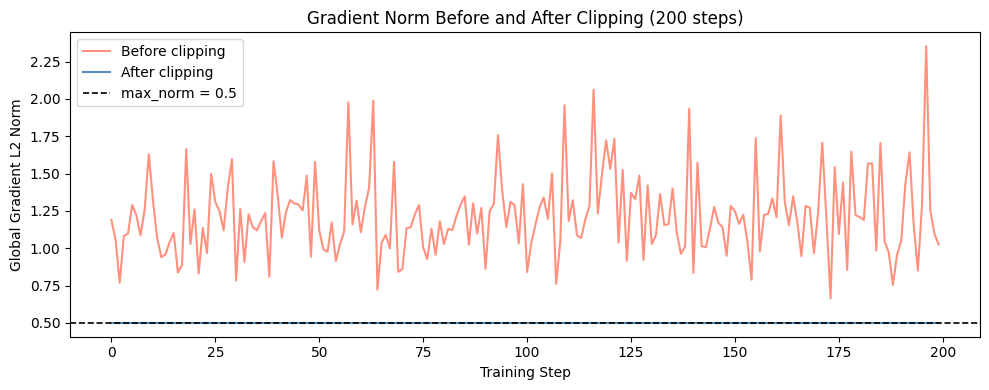


  Average norm before : 1.2153
  Average norm after  : 0.5000
  Max norm after      : 0.500000  (should be ≤ 0.5)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4: Gradient Clipping
# ─────────────────────────────────────────────────────────────────────────────
# Exploding gradients are a common failure mode in RL training:
#   • Long episodes → deep unrolled computation graphs → vanishing/exploding grads
#   • High-variance policy gradient estimates amplify gradient magnitude
#
# torch.nn.utils.clip_grad_norm_(params, max_norm) rescales ALL gradients
# so the global L2 norm is at most max_norm, preserving direction.
#
# We reuse the SharedActorCritic from Task 1b and run a full training step,
# printing the gradient norm BEFORE and AFTER clipping to confirm it works.



MAX_GRAD_NORM = 0.5   # maximum allowed global gradient L2 norm

# ── Fresh model and optimizer for this demonstration ─────────────────────────
model_gc     = SharedActorCritic(INPUT_DIM, HIDDEN_DIM, N_ACTIONS)
optimizer_gc = optim.Adam(model_gc.parameters(), lr=LR)

# ── Forward pass with dummy data ──────────────────────────────────────────────
action_probs_gc, values_gc = model_gc(dummy_obs)

advantages_gc = dummy_returns - values_gc.detach()   # advantage baseline

dist_gc      = torch.distributions.Categorical(action_probs_gc)
actions_gc   = dist_gc.sample()
log_probs_gc = dist_gc.log_prob(actions_gc)
entropy_gc   = dist_gc.entropy()

# ── Loss computation ──────────────────────────────────────────────────────────
actor_loss_gc  = -(log_probs_gc * advantages_gc.squeeze()).mean() - ENT_COEF * entropy_gc.mean()
critic_loss_gc = F.mse_loss(values_gc.squeeze(), dummy_returns.squeeze())
total_loss_gc  = actor_loss_gc + VF_COEF * critic_loss_gc

# ── Backward pass: compute all gradients ─────────────────────────────────────
optimizer_gc.zero_grad()
total_loss_gc.backward()

# ── Helper: compute global L2 gradient norm ──────────────────────────────────
def compute_grad_norm(model: nn.Module) -> float:
    """
    Returns the global L2 norm of all parameter gradients.
    sqrt( sum_p ||grad_p||^2 )
    """
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    return total_norm ** 0.5


# ── Print norm BEFORE clipping ────────────────────────────────────────────────
norm_before = compute_grad_norm(model_gc)
print("─────────────────────────────────────────────")
print(f"  Gradient norm BEFORE clipping : {norm_before:.6f}")
print(f"  Max norm threshold            : {MAX_GRAD_NORM}")

# ── Apply gradient clipping ───────────────────────────────────────────────────
# clip_grad_norm_ returns the total norm BEFORE clipping (convenient)
returned_norm = torch.nn.utils.clip_grad_norm_(model_gc.parameters(), max_norm=MAX_GRAD_NORM)

# ── Print norm AFTER clipping ─────────────────────────────────────────────────
norm_after = compute_grad_norm(model_gc)
print(f"  Gradient norm AFTER clipping  : {norm_after:.6f}")
print(f"  Norm returned by clip_grad    : {returned_norm:.6f}  (pre-clip norm)")
print("─────────────────────────────────────────────")

# ── Verification ─────────────────────────────────────────────────────────────
clipping_applied = norm_before > MAX_GRAD_NORM
print(f"  Clipping was applied          : {clipping_applied}")
if clipping_applied:
    print(f"  Gradients rescaled by factor  : {MAX_GRAD_NORM / norm_before:.6f}")
    print(f"  ✓ Norm correctly bounded to ≤ {MAX_GRAD_NORM}")
else:
    print(f"  Norm was already ≤ {MAX_GRAD_NORM} — no rescaling needed.")

# ── Optimizer step ────────────────────────────────────────────────────────────
# The step should be called AFTER clipping, not before.
optimizer_gc.step()
print("\n  Optimizer step applied after gradient clipping.")
print("  Parameters updated successfully.")


# ── Visualisation: gradient norms before and after clipping ──────────────────
# Run multiple forward passes with different random data to build a distribution

norms_before, norms_after = [], []

for _ in range(200):
    # Fresh random batch
    obs_batch     = torch.randn(BATCH_SIZE, INPUT_DIM)
    returns_batch = torch.randn(BATCH_SIZE, 1)

    # Forward & loss
    ap, vl = model_gc(obs_batch)
    adv    = returns_batch - vl.detach()
    d      = torch.distributions.Categorical(ap)
    lp     = d.log_prob(d.sample())
    ent    = d.entropy()
    loss   = -(lp * adv.squeeze()).mean() - ENT_COEF * ent.mean() + VF_COEF * F.mse_loss(vl.squeeze(), returns_batch.squeeze())

    optimizer_gc.zero_grad()
    loss.backward()

    norms_before.append(compute_grad_norm(model_gc))
    torch.nn.utils.clip_grad_norm_(model_gc.parameters(), max_norm=MAX_GRAD_NORM)
    norms_after.append(compute_grad_norm(model_gc))
    optimizer_gc.step()


# Plot
plt.figure(figsize=(10, 4))
plt.plot(norms_before, label='Before clipping', alpha=0.7, color='tomato')
plt.plot(norms_after,  label='After clipping',  alpha=0.9, color='steelblue')
plt.axhline(y=MAX_GRAD_NORM, color='black', linestyle='--', linewidth=1.2, label=f'max_norm = {MAX_GRAD_NORM}')
plt.xlabel('Training Step')
plt.ylabel('Global Gradient L2 Norm')
plt.title('Gradient Norm Before and After Clipping (200 steps)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n  Average norm before : {np.mean(norms_before):.4f}")
print(f"  Average norm after  : {np.mean(norms_after):.4f}")
print(f"  Max norm after      : {max(norms_after):.6f}  (should be ≤ {MAX_GRAD_NORM})")



### Discussion – Task 4: Why clip gradients?

In RL, gradients can **spike** (one huge update). That can throw weights off.

Typical causes:

1. **Noisy policy gradients** — early advantages are rough.
2. **Big returns** — long or high-reward episodes inflate targets.
3. **Shared trunk** — a big value gradient can shake layers the policy also uses.

**What `clip_grad_norm_` does:**
It measures the **total size** of all gradients (L2 norm). If it is bigger than `max_norm`, it **scales all gradients down** by the same factor so the total size equals `max_norm`. Direction stays the same; only step size is capped.

The plot should show **after** norms stay at or below **`max_norm = 0.5`**, even when the raw norm spikes higher.
